# [CS 4476 Problem Set 2: Local Feature Matching](https://faculty.cc.gatech.edu/~judy/cs4476-sp22/)

This Jupyter notebook:  
(1) Loads and resizes images  
(2) Finds interest points in those images                 (you code this)  
(3) Describes each interest point with a local feature    (you code this)  
(4) Finds matching features                               (you code this)  
(5) Visualizes the matches  
(6) Evaluates the matches based on ground truth correspondences  

## Setup

In [368]:
%matplotlib notebook
%load_ext autoreload
%autoreload 2
import os
import cv2
import numpy as np
import time
import matplotlib.pyplot as plt
from utils import *
from student_feature_matching import match_features, pca, accelerated_matching
from student_sift import get_features
from student_harris import get_interest_points
from IPython.core.debugger import set_trace


from ps2_unit_tests.harris_unit_test import (
    test_get_gradients,
    test_get_gradients2,
    test_gaussian_kernel, 
    test_second_moment, 
    test_corner_response, 
    test_get_interest_points,
    test_find_single_valid_corner,
    verify
)
from ps2_unit_tests.sift_unit_test import (
    test_get_magnitudes_and_orientations,
    test_get_feat_vec,
    test_get_features, 
)

from ps2_unit_tests.feature_match_test import (
    test_compute_dists,
    test_feature_matching,
    test_pca
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [369]:
%matplotlib inline

## Part 1: Local Feature Matching using SIFT
#### Loading and Resizing Images

In [370]:
'''
We recommend starting with the Notre Dame image pair.

When you want to test out the other 2 pairs of images (Mount Rushmore, Episcopal Gaudi),
you need to comment out the code for the other 2 images pairs and RERUN ALL cells below.
''' 

# Notre Dame
#image1 = load_image('../data/Notre Dame/921919841_a30df938f2_o.jpg')
#image2 = load_image('../data/Notre Dame/4191453057_c86028ce1f_o.jpg')
#eval_file = '../data/Notre Dame/921919841_a30df938f2_o_to_4191453057_c86028ce1f_o.pkl'

# Mount Rushmore -- this pair is relatively easy (still harder than Notre Dame, though)
image1 = load_image('../data/Mount Rushmore/9021235130_7c2acd9554_o.jpg')
image2 = load_image('../data/Mount Rushmore/9318872612_a255c874fb_o.jpg')
eval_file = '../data/Mount Rushmore/9021235130_7c2acd9554_o_to_9318872612_a255c874fb_o.pkl'

#Episcopal Gaudi -- This pair is relatively difficult
#image1 = load_image('../data/Episcopal Gaudi/4386465943_8cf9776378_o.jpg')
#image2 = load_image('../data/Episcopal Gaudi/3743214471_1b5bbfda98_o.jpg')
#eval_file = '../data/Episcopal Gaudi/4386465943_8cf9776378_o_to_3743214471_1b5bbfda98_o.pkl'

                    
scale_factor = 0.5
image1 = cv2.resize(image1, (0, 0), fx=scale_factor, fy=scale_factor)
image2 = cv2.resize(image2, (0, 0), fx=scale_factor, fy=scale_factor)
image1_bw = cv2.cvtColor(image1, cv2.COLOR_RGB2GRAY)
image2_bw = cv2.cvtColor(image2, cv2.COLOR_RGB2GRAY)

n_pts = 1500 # width and height of each local feature, in pixels. 

## 1.1 Interest Point Detection (student_harris.py)
#### Find distinctive points in each image (Szeliski 4.1.1)
These are the results using the ground truth points

Note: Image may take some time to appear 

If you face 'the STRING opcode argument must be quoted' error, simply reopen the 'pkl' file for image loacted in data folder  in VScode. Chage the CRLF to LF at the bottome right corner of VScode.

126 corners in image 1, 126 corners in image 2


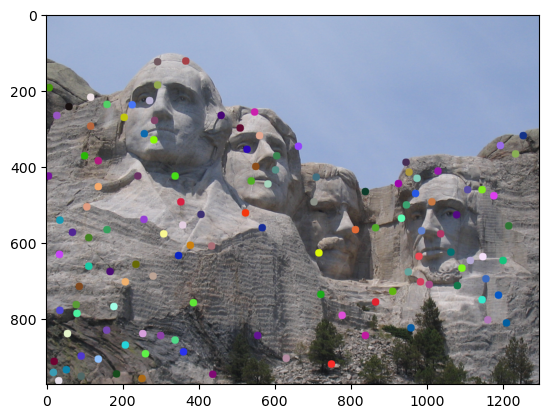

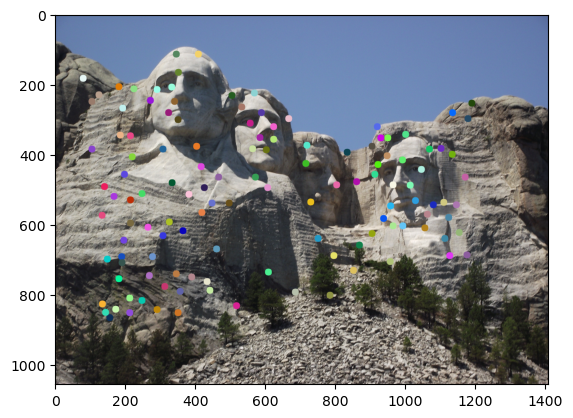

In [371]:
x1, y1, x2, y2 = cheat_interest_points(eval_file, scale_factor)

# Visualize the interest points
c1 = show_interest_points(image1, x1, y1)
c2 = show_interest_points(image2, x2, y2)
plt.figure(); plt.imshow(c1)
plt.figure(); plt.imshow(c2)
print('{:d} corners in image 1, {:d} corners in image 2'.format(len(x1), len(x2)))

This is where you implement and observe your results from `get_interest_points()` in student_harris.py

Be sure to complete `get_gradients()`, `second_moments()`, `corner_response()`, `non_max_suppression()`, `remove_border_vals()` before completing this function.

Hints

(1) In order to compute the Corner Response Scores, look at how you can use the outputs from `get_gradients()` method and `second_moments()` method.

(2) Once you have these scores, consider how you might transform the matrix given to you to extract the indices and sort them.



#### First some unit tests

In [372]:
## Verify each step in the code, this will check if your implementation is correct or not.

## Do not modify the constructor of any function (i.e. to take some custom arguments as input)

print("Gaussian Kernel:", verify(test_gaussian_kernel))
print('Gradients test 1:', verify(test_get_gradients))
print('Gradients test 2:', verify(test_get_gradients2))
print('Second Moments:', verify(test_second_moment))
print('Corner Response:', verify(test_corner_response))

Gaussian Kernel: "Correct"
Gradients test 1: "Correct"
Gradients test 2: "Correct"
Second Moments: "Correct"
Corner Response: "Correct"


#### Now run it all together

1500 corners in image 1, 1500 corners in image 2


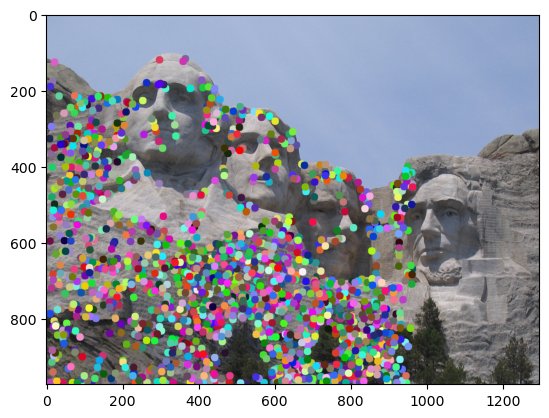

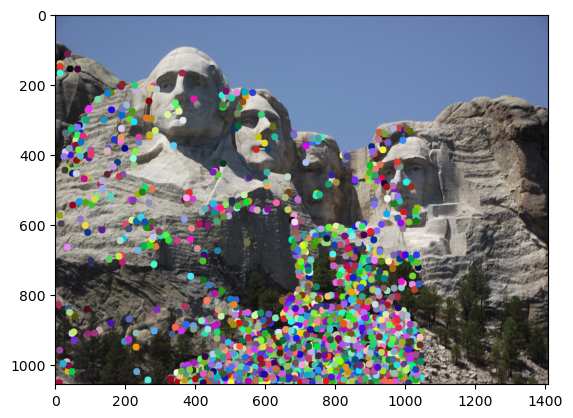

In [373]:
x1, y1, R1, _= get_interest_points(image1_bw, n_pts)
x2, y2, R2, _= get_interest_points(image2_bw, n_pts)
c1 = show_interest_points(image1, x1, y1)
c2 = show_interest_points(image2, x2, y2)
plt.figure(); plt.imshow(c1)
plt.figure(); plt.imshow(c2)
print('{:d} corners in image 1, {:d} corners in image 2'.format(len(x1), len(x2)))

In [374]:
print('Interest Points:', verify(test_get_interest_points))
print('Interest Points Single Corner:', verify(test_find_single_valid_corner))

Interest Points: "Correct"
Interest Points Single Corner: "Correct"


## 1.2 Local Feature Description (student_sift.py)
#### Create feature vectors at each interest point (Szeliski 4.1.2)

This is where you will code the functions `get_magnitudes_and_orientations()`, `get_feat_vec()`, and `get_features()` in `student_sift.py`.

Run the following cells to test your implementation.

In [375]:
print("Magnitudes and Orientations:", verify(test_get_magnitudes_and_orientations))
print('Feature Vector', verify(test_get_feat_vec))
print('All Feature Vectors', verify(test_get_features))

Magnitudes and Orientations: "Correct"
Feature Vector "Correct"
All Feature Vectors "Correct"


#### Collect features from our image pair

In [376]:
feature_width = 16
image1_features = get_features(image1_bw, x1, y1, feature_width)
image2_features = get_features(image2_bw, x2, y2, feature_width)

## 1.3 Feature Matching (student_feature_matching.py)
#### Match features (Szeliski 4.1.3)

Complete `compute_feature_distances()` and `match_features()` in `student_feature_matching.py`. The following cell will test your implementations

In [377]:
print("Feature Distances:", verify(test_compute_dists))
print('Matches:', verify(test_feature_matching))

Feature Distances: "Correct"
Matches: "Correct"


#### Match features for our image pair

In [378]:
start = time.time()
matches, confidences = match_features(image1_features, image2_features)
end = time.time()
unoptimized = end - start
print('{:d} matches from {:d} corners'.format(len(matches), len(x1)))
print('Time Elapsed: {}'.format(unoptimized))

107 matches from 1500 corners
Time Elapsed: 1.765857219696045


#### Visualization

You might want to set 'num_pts_to_visualize' and 'num_pts_to_evaluate' to some constant (e.g. 100) once you start detecting hundreds of interest points, otherwise things might get too cluttered. You could also threshold based on confidence. You may use different NNDR ratios per image if you would like to experiment per-image, but this is not required/expected.

There are two visualization functions below. **Note: For the report, use the visualization that shows correspondence lines (not circles)**.

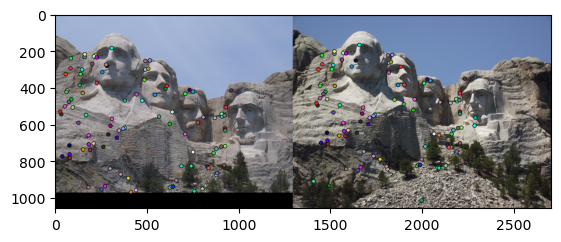

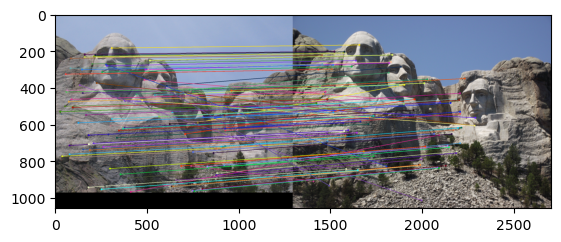

In [379]:
# num_pts_to_visualize = len(matches)
num_pts_to_visualize = 100
c1 = show_correspondence_circles(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c1)
os.makedirs('../results', exist_ok=True)
plt.savefig('../results/vis_circles.png', dpi=1000)

c2 = show_correspondence_lines(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c2)
plt.savefig('../results/vis_lines.png', dpi=1000)

Comment out the function below if you are not testing on the Notre Dame, Episcopal Gaudi, and Mount Rushmore image pairs--this evaluation function will only work for those which have ground truth available.  
  
You can use `collect_ground_truth_corr.py` to build the ground truth for other image pairs if you want, but it's very tedious. It would be a great service to the class for future years, though!

You found 100/100 required matches
Accuracy = 0.820000


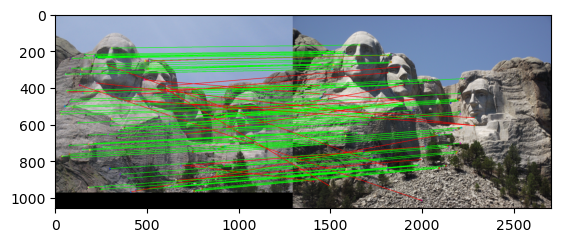

In [380]:
# num_pts_to_evaluate = len(matches)
num_pts_to_evaluate = 100
_, c = evaluate_correspondence(image1, image2, eval_file, scale_factor,
                        x1[matches[:num_pts_to_evaluate, 0]], y1[matches[:num_pts_to_evaluate, 0]],
                        x2[matches[:num_pts_to_evaluate, 1]], y2[matches[:num_pts_to_evaluate, 1]])
plt.figure(); plt.imshow(c)
plt.savefig('../results/eval.png', dpi=1000)

## 1.4 Bells and Whistles (Extra Credit)

Complete `pca()` and `accelerated_matching()` in `student_feature_matching.py`. The following cells will test your implementations

### PCA

#### Unit Tests for PCA

In [382]:
print("PCA: ", verify(test_pca))

PCA:  "Correct"


In [383]:
n_components = 24
start = time.time()
reduced_image1_features, reduced_image2_features = pca(image1_features, image2_features, n_components)
matches, confidences = match_features(reduced_image1_features, reduced_image2_features)
end = time.time()
pca_optimized = end - start
print('{:d} matches from {:d} corners'.format(len(matches), len(x1)))
print('Time Elapsed (PCA): {}'.format(pca_optimized))
print('Time Elapsed (no optimization): {}'.format(unoptimized))

156 matches from 1500 corners
Time Elapsed (PCA): 0.16740751266479492
Time Elapsed (no optimization): 1.765857219696045


**Note: For the report, use the visualization that shows correspondence lines (not circles)**

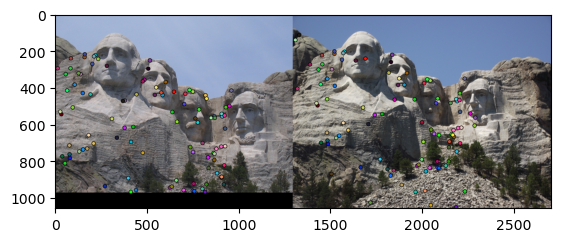

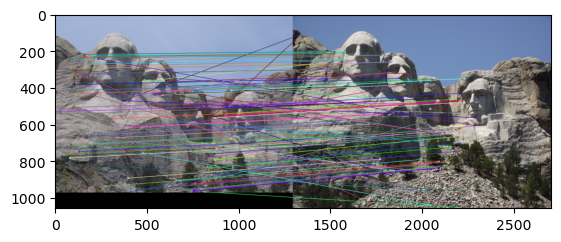

In [384]:
# num_pts_to_visualize = len(matches)
num_pts_to_visualize = 100
c1 = show_correspondence_circles(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c1)
plt.savefig('../results/vis_circles_pca.png', dpi=1000)
c2 = show_correspondence_lines(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c2)
plt.savefig('../results/vis_lines_pca.png', dpi=1000)

You found 100/100 required matches
Accuracy = 0.650000


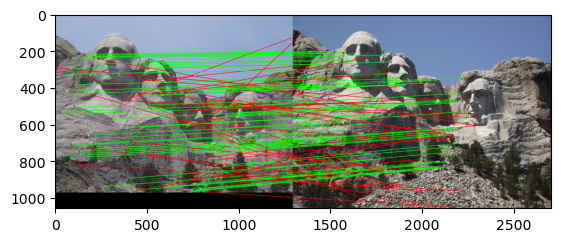

In [385]:
# num_pts_to_evaluate = len(matches)
num_pts_to_evaluate = 100
_, c = evaluate_correspondence(image1, image2, eval_file, scale_factor,
                        x1[matches[:num_pts_to_evaluate, 0]], y1[matches[:num_pts_to_evaluate, 0]],
                        x2[matches[:num_pts_to_evaluate, 1]], y2[matches[:num_pts_to_evaluate, 1]])
plt.figure(); plt.imshow(c)
plt.savefig('../results/eval_pca.png', dpi=1000)

### Accelerated Matching

##### For full credit, the time elapsed must be under a second for matching.

In [ ]:
start = time.time()
matches, confidences = accelerated_matching(image1_features, image2_features)
end = time.time()
accelerated = end - start
print('{:d} matches from {:d} corners'.format(len(matches), len(x1)))
print('Time Elapsed (Accelerated): {}'.format(accelerated))
print('Time Elapsed (PCA): {}'.format(pca_optimized))
print('Time Elapsed (no optimization): {}'.format(unoptimized))

**Note: For the report, use the visualization that shows correspondence lines (not circles)**

In [ ]:
# num_pts_to_visualize = len(matches)
num_pts_to_visualize = 100
c1 = show_correspondence_circles(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c1)
plt.savefig('../results/vis_circles_am.png', dpi=1000)
c2 = show_correspondence_lines(image1, image2,
                    x1[matches[:num_pts_to_visualize, 0]], y1[matches[:num_pts_to_visualize, 0]],
                    x2[matches[:num_pts_to_visualize, 1]], y2[matches[:num_pts_to_visualize, 1]])
plt.figure(); plt.imshow(c2)
plt.savefig('../results/vis_lines_am.png', dpi=1000)

In [ ]:
# num_pts_to_evaluate = len(matches)
num_pts_to_evaluate = 100
_, c = evaluate_correspondence(image1, image2, eval_file, scale_factor,
                        x1[matches[:num_pts_to_evaluate, 0]], y1[matches[:num_pts_to_evaluate, 0]],
                        x2[matches[:num_pts_to_evaluate, 1]], y2[matches[:num_pts_to_evaluate, 1]])
plt.figure(); plt.imshow(c)
plt.savefig('../results/eval_am.png', dpi=1000)